In [1]:
# !pip install dendropy
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from dendropy.simulate import treesim
from scipy.special import logit, expit
from tqdm import tqdm
from aux_fns import *

from matplotlib import colors as mcolors
from matplotlib.patches import Patch

set_ggplot_light_theme()

%load_ext autoreload
%autoreload 2

In [2]:
save_path = "/Users/elenab/Dropbox/work/00_THESIS/figures/cellsnp/"

# Simulate the tree and cluster the cells

In [3]:
V, N, K = 1000, 500, 4

tree = treesim.birth_death_tree(birth_rate=1.0, death_rate=0.5, num_extant_tips=N, rng=random.Random(10))

In [4]:
import os

def assign_clones_from_tree(tree, K):
    tree.phylogenetic_distance_matrix().as_data_table().write_csv("distances.csv")
    distances_df = pd.read_csv("distances.csv", index_col=0)
    cell_ids = list(distances_df.index)

    distances = squareform(np.array(distances_df.values), checks=False)    
    linkage_matrix = linkage(distances, method="complete")
    clone_ids = fcluster(linkage_matrix, K, criterion="maxclust")
    os.remove("distances.csv")
    return {cell_id:clone_id for cell_id,clone_id in zip(cell_ids,clone_ids)}, linkage_matrix

assignments, linkage_matrix = assign_clones_from_tree(tree, K)  # dict: {cell_id:clone_id, ...}
cell_ids = list(assignments.keys())
clone_ids = list(assignments.values())

In [5]:
# pd.DataFrame(linkage_matrix).to_csv("~/Dropbox/work/00_THESIS/figures/cellsnp/linkage_matrix.csv", index=False)
# pd.DataFrame({"cell_id": cell_ids, "clone_id": clone_ids}).to_csv("~/Dropbox/work/00_THESIS/figures/cellsnp/cell_groups.csv", index=False)

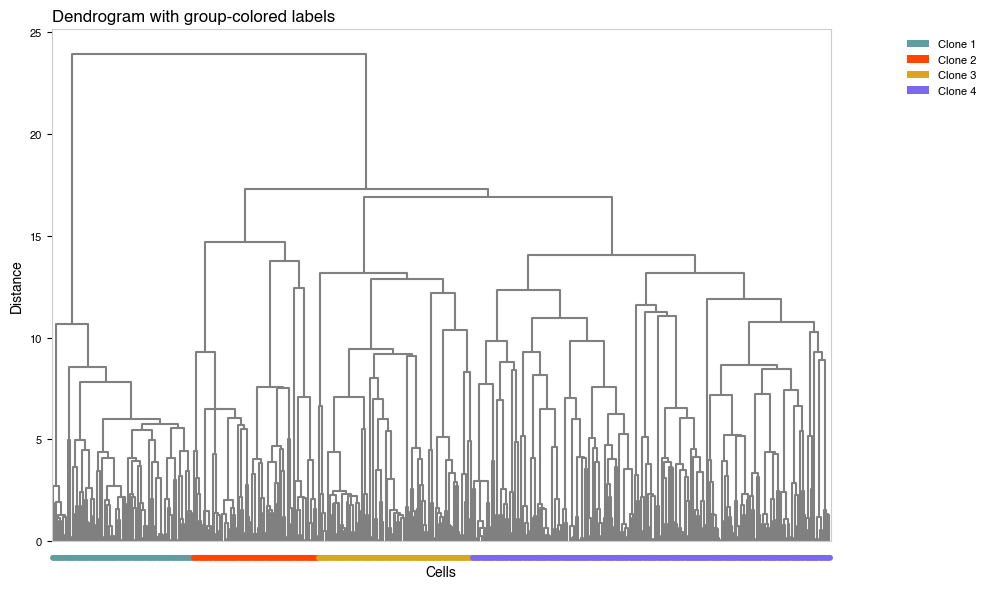

In [6]:
%matplotlib inline
unique_groups = set(clone_ids)
color_list = ["#5F9EA0","#FF4500","#DAA520","#7B68EE"]
color_map = {group: color_list[i % len(color_list)] for i, group in enumerate(unique_groups)}
label_colors = [color_map[group] for group in clone_ids]
symbol_labels = ['●'] * len(cell_ids)

plt.figure(figsize=(10, 6))
dendro = dendrogram(linkage_matrix, color_threshold=0, above_threshold_color="grey", labels=symbol_labels, leaf_font_size=10)
leaf_order = dendro["leaves"]
groupings_ordered = np.array(clone_ids)[leaf_order]

ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for lbl, group in zip(xlbls, groupings_ordered):
    lbl.set_color(color_map[group])

legend_elements = [Patch(facecolor=color_map[g], label=f'Clone {g}') for g in unique_groups]

plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.title('Dendrogram with group-colored labels', loc="left")
plt.ylabel('Distance')
plt.xlabel('Cells')
plt.grid(visible=False)
plt.tight_layout()
plt.savefig(save_path+"dendogram.pdf", dpi=600)
plt.show()

# Compute the OU kernel

In [7]:
def tree_to_edge_list(tree):
    edge_list = []
    for edge in tree.edges():
        parent = edge.tail_node  # parent node
        child = edge.head_node  # child node

        if parent is None:
            continue

        branch_length = edge.length  # branch length

        parent_label = parent.label or (parent.taxon.label if parent.taxon else None) or str(id(parent))
        child_label = child.label or (child.taxon.label if child.taxon else None) or str(id(child))
        
        edge_list.append([parent_label, child_label, branch_length])

    return edge_list

edges = tree_to_edge_list(tree)

In [8]:
kernel = compute_ou_kernel(edges, list(assignments.keys()), lambd=.05, sigma_squared=1.0)
pd.DataFrame(kernel).to_csv(save_path + "kernel.csv", index=False)

assert kernel.shape[0] == kernel.shape[1]
assert kernel.shape[0] == N

[]

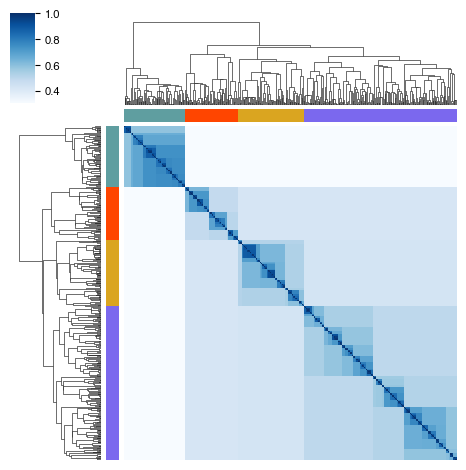

In [9]:
g = sns.clustermap(kernel, col_colors=[color_map[i] for i in clone_ids], 
                   row_colors=[color_map[i] for i in clone_ids],
                   col_linkage=linkage_matrix, row_linkage=linkage_matrix,
                   cmap="Blues", figsize=(5, 5))

g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_yticks([])
# g.fig.savefig(save_path+"kernel.pdf")

# Simulate mu

Here we have 4 clones with phylogeny like this

```
    M
   / \
 C1   /\
     C2 /\
       C3 C4
```

Therefore, we need to simulate
- clonal mutations (shared)
- shared mutations between C2, C3, C4
- shared mutations between C3, C4
- private mutations

In [10]:
def alpha(phi, kappa):
    return phi * kappa

def beta(phi, kappa):
    return (1-phi) * kappa

def compute_mean_frequency(k_list):
    return len([c for c in clone_ids if c in k_list]) / len(clone_ids) / 2

def get_indexes(k_list):
    return [i for i,v in enumerate(clone_ids) if v in k_list]

def sample_beta(k_list, size_rows, N):
    idxs = get_indexes(k_list)
    samples = np.zeros((size_rows, N)) + logit_0
    vaf = np.random.beta(1., 1.)
    print(vaf)
    vaf = compute_mean_frequency(k_list)
    alpha_par = alpha(vaf, kappa)
    beta_par = beta(vaf, kappa)
    samples[:, idxs] = logit(np.random.beta(alpha_par, beta_par, size=(size_rows, len(idxs))))
    return samples

logit_0 = logit(1e-10)

mu_true = np.zeros((V, N))
idxs = [i for i in range(V)]
clonal_mutations = np.random.choice(idxs, size=int(V * 0.3), replace=False)  # 30% of muts will be clonal
[idxs.remove(_) for _ in clonal_mutations]

shared_234 = np.random.choice(idxs, size=int(V * 0.2), replace=False)  # 20% of muts will be clonal
[idxs.remove(_) for _ in shared_234]

shared_34 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in shared_34]

private_1 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_1]

private_2 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_2]

private_3 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_3]

private_4 = np.random.choice(idxs, size=int(V * 0.1), replace=False)  # 10% of muts will be clonal
[idxs.remove(_) for _ in private_4]

assert len(idxs) == 0

kappa = 50
# mu_true[clonal_mutations,:] = np.random.beta(alpha(0.5, kappa), beta(0.5, kappa), size=(len(clonal_mutations), N))
mu_true[clonal_mutations,:] = sample_beta([1,2,3,4], len(clonal_mutations), N)

mu_true[shared_234,:] = sample_beta([2,3,4], len(shared_234), N)
mu_true[shared_34,:] = sample_beta([3,4], len(shared_34), N)

mu_true[private_1,:] = sample_beta([1], len(private_1), N)
mu_true[private_2,:] = sample_beta([2], len(private_2), N)
mu_true[private_3,:] = sample_beta([3], len(private_3), N)
mu_true[private_4,:] = sample_beta([4], len(private_4), N)

0.05247478030676118
0.5707468075639828
0.058361211772322945
0.2853580060802069
0.9599537669006248
0.24052083703607294
0.3214916888961641


# Simulate gamma and sample observed variables

In [11]:
# gamma_true = np.zeros((V, N))
# for v in range(V):
#     gamma_true[v,:] = np.random.multivariate_normal(mu_true[v,:], kernel)

gamma_true = mu_true
# which_zeros = gamma_true == 0
theta_true = expit(gamma_true)
# theta_true[which_zeros] = 0.0
DP_true = np.full((V,N), 100) + np.round(np.random.normal(0, 1, size=(V,N))).astype(int)
AD_true = np.random.binomial(DP_true, theta_true)

pd.DataFrame(gamma_true).to_csv(save_path + "gamma_true.csv", index=False)
pd.DataFrame(theta_true).to_csv(save_path + "theta_true.csv", index=False)
pd.DataFrame(DP_true).to_csv(save_path + "DP_true.csv", index=False)
pd.DataFrame(AD_true).to_csv(save_path + "AD_true.csv", index=False)

In [12]:
def array_to_df(array, value_name):
    df = pd.DataFrame(array)
    df.columns = cell_ids
    df["mutation_ids"] = df.index
    df = pd.melt(df, id_vars=["mutation_ids"], value_vars=cell_ids, var_name="cell_ids", value_name=value_name)
    return df

In [13]:
data_true = pd.concat([array_to_df(theta_true, "VAF"), \
                       array_to_df(AD_true, "AD")["AD"], \
                       array_to_df(DP_true, "DP")["DP"], \
                       array_to_df(gamma_true, "gamma")["gamma"]], \
                       axis=1, join="inner")
data_true["clone_ids"] = [str(assignments[i]) for i in data_true["cell_ids"]]
data_true.head()

,mutation_ids,cell_ids,VAF,AD,DP,gamma,clone_ids
0,0,T406,1.000000e-10,0,99,-23.025851,2
1,1,T406,1.000000e-10,0,99,-23.025851,2
2,2,T406,4.530851e-01,45,100,-0.188213,2
3,3,T406,4.073179e-01,44,101,-0.375064,2
4,4,T406,3.236386e-01,32,101,-0.737100,2


/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


[]

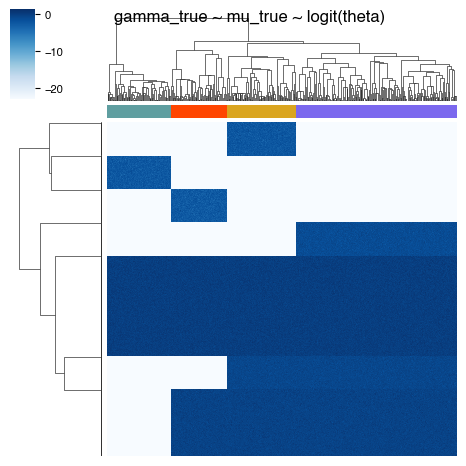

In [14]:
pl = sns.clustermap(gamma_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
pl.fig.suptitle("gamma_true ~ mu_true ~ logit(theta)")

pl.ax_heatmap.set_xticks([])
pl.ax_heatmap.set_yticks([])
# plt.savefig(save_path + "gamma_true.pdf")

/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


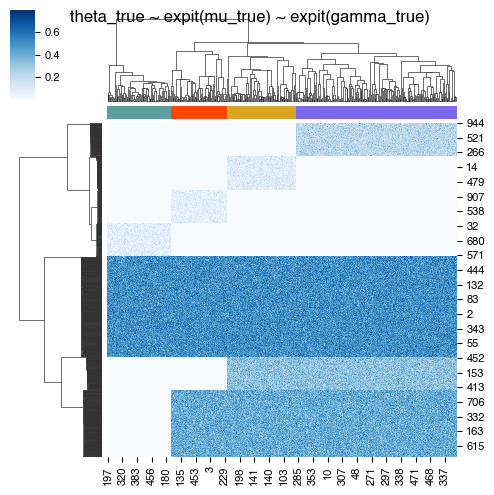

In [15]:
pl = sns.clustermap(theta_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
pl = pl.fig.suptitle("theta_true ~ expit(mu_true) ~ expit(gamma_true)")

/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


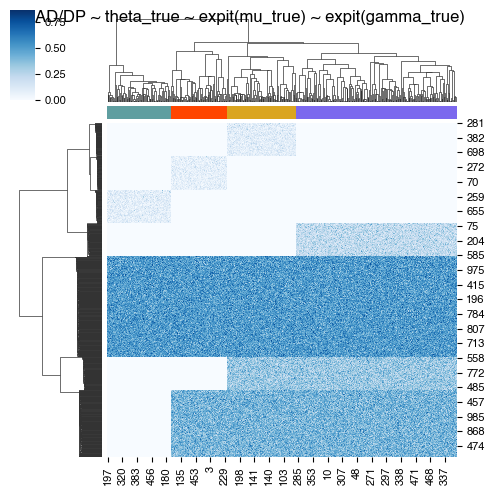

In [16]:
pl = sns.clustermap(AD_true/DP_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
pl = pl.fig.suptitle("AD/DP ~ theta_true ~ expit(mu_true) ~ expit(gamma_true)")

# Run the model

In [21]:
import torch
import time
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torch.autograd.functional import hessian
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# device = torch.device("cuda")
# device = torch.device("mps")
device = torch.device("cpu")

In [19]:
# convert to tensor the data
Y = torch.tensor(AD_true).to(device=device)
D = torch.tensor(DP_true).to(device=device)
Z = torch.tensor(clone_ids, dtype=torch.int, device=device)

V, N = Y.shape  # #mutations x #cells
K = len(Z.unique())  # #clones

learning_rate = 0.005

assert Y.shape[1] == D.shape[1]
assert Y.shape[1] == Z.shape[0]
print(f"{V} SNPs, {N} cells and {K} clones\n")

print(f"Devices\nY = {Y.device}\nD = {D.device}\nZ = {Z.device}")

1000 SNPs, 500 cells and 4 clones

Devices
Y = cpu
D = cpu
Z = cpu


Initialize the parameters and optimizer, and run the inference

In [20]:
# Initialize mu
mu_init = logit_clipped(Y/D)  # initialize mu as a sampling from a beta(1,1)
mu = mu_init.detach().clone().requires_grad_(True)

# Initialize gamma
# gamma_hat_init = logit_clipped(Y/D) + torch.normal(mean=torch.zeros_like(Y, dtype=torch.float32), std=torch.ones_like(Y, dtype=torch.float32))
gamma_hat_init = torch.randn_like(mu)
gamma_hat = mu_init.detach().clone().requires_grad_(False)

# Initialize the covariance matrix
Sigma = torch.tensor(kernel, dtype=torch.float32, device=device) + 1e-6*torch.eye(N, device=device)
Sigma_inv = torch.linalg.inv(Sigma)  # inverese of Sigma -> N x N
log_det_Sigma = torch.logdet(Sigma)  # log of determinant of Sigma

# Check the device of all parameters
print(f"Devices\nmu = {mu.device}\nSigma = {Sigma.device}\nSigma_inv = {Sigma_inv.device}\nlog_det_Sigma = {log_det_Sigma.device}\ngamma_hat = {gamma_hat.device}")

# Optimizer
optimizer = optim.Adam([mu], lr=learning_rate)

# Store initial time and lists
start_time = time.time()
losses, gradients = [], []

# Start the inference
pbar = tqdm(range(50))
for _ in pbar:
    optimizer.zero_grad()  # reset the gradient

    total_laplace = 0.0
    for v in range(V):
        # compute log p(y_v | d_v, mu_v, Sigma) with laplace approx
        y_v = Y[v, :]
        d_v = D[v, :]
        laplace_term, gamma_hat_v = compute_laplace_term(y_v, d_v, mu[v,:], Sigma_inv, gamma_hat[v,:])
        total_laplace += laplace_term
        gamma_hat[v,:] = gamma_hat_v

    loss = -total_laplace
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    gradients.append(mu.grad.norm().item())

    pbar.set_description(f"Loss = {loss.item()}")

# Store final time
end_time = time.time()

Devices
mu = cpu
Sigma = cpu
Sigma_inv = cpu
log_det_Sigma = cpu
gamma_hat = cpu


Loss = 1134202.75: 100%|██████████| 50/50 [14:06<00:00, 16.93s/it] 


# Evaluation

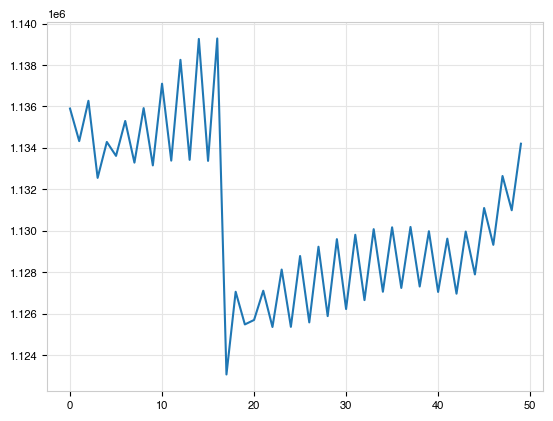

In [22]:
plt.plot(losses)
# plt.plot(gradients)

/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


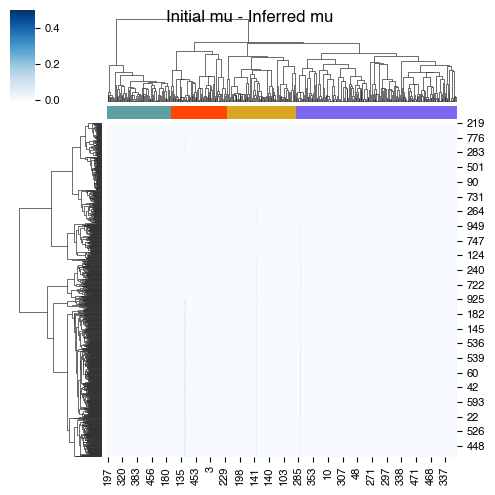

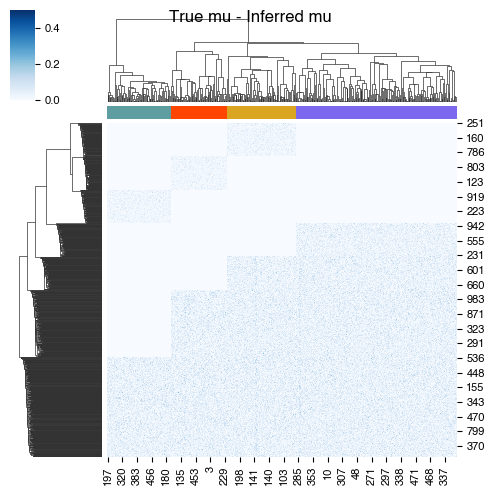

In [23]:
mu_np = mu.cpu().detach().numpy()
# pl1 = sns.clustermap(mu_np, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
# pl1 = pl1.fig.suptitle("Inferred mu")

# pl2 = sns.clustermap(mu_init.cpu(), col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 8))
# pl2 = pl2.fig.suptitle("Initial mu")

pl1 = sns.clustermap(np.abs(expit(mu_init.cpu().numpy()) - expit(mu_np)),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0., vmax=0.5,
                     figsize=(5, 5))
pl1 = pl1.fig.suptitle("Initial mu - Inferred mu")

pl3 = sns.clustermap(np.abs(expit(mu_true) - expit(mu_np)),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0., vmax=0.5,
                     figsize=(5, 5))
pl3 = pl3.fig.suptitle("True mu - Inferred mu")

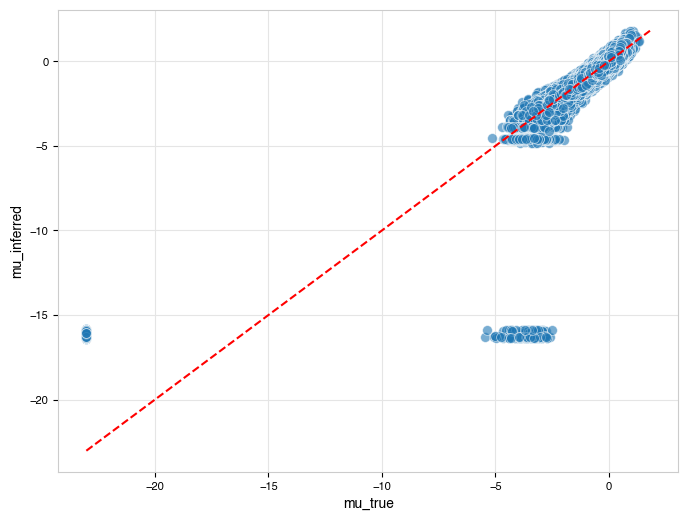

In [24]:
df = pd.DataFrame({"mu_true": mu_true.flatten(), "mu_inferred": mu_np.flatten()})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="mu_true", y="mu_inferred", alpha=0.6, s=50, edgecolor="w")
min_val = min(np.min(df.mu_true), np.min(df.mu_inferred))
max_val = max(np.max(df.mu_true), np.max(df.mu_inferred))
plt.plot([min_val, max_val], [min_val, max_val], "r--")

/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


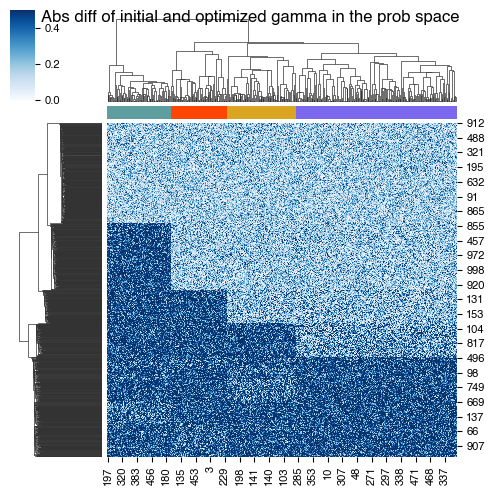

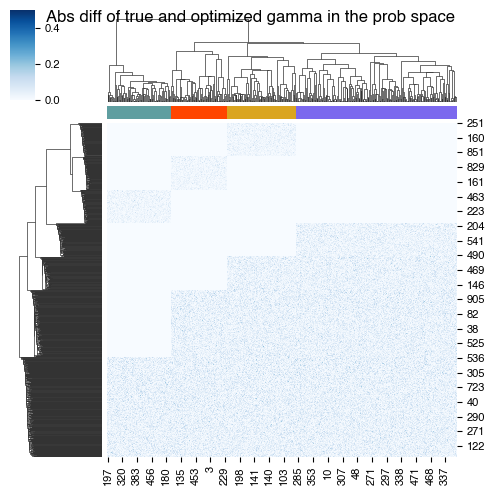

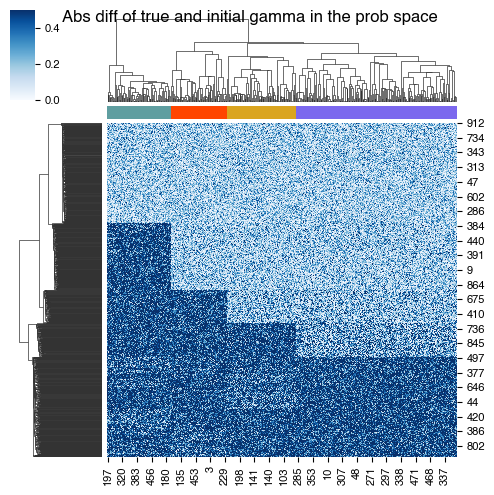

In [25]:
pl1 = sns.clustermap(np.abs(expit(gamma_hat_init.cpu().numpy()) - expit(gamma_hat.cpu().numpy())),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0, vmax=0.5,
                     figsize=(5, 5))
pl1 = pl1.fig.suptitle("Abs diff of initial and optimized gamma in the prob space")

pl2 = sns.clustermap(np.abs(expit(gamma_true) - expit(gamma_hat.cpu().numpy())),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0, vmax=0.5,
                     figsize=(5, 5))
pl2 = pl2.fig.suptitle("Abs diff of true and optimized gamma in the prob space")

pl3 = sns.clustermap(np.abs(expit(gamma_true) - expit(gamma_hat_init.cpu().numpy())),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0, vmax=0.5,
                     figsize=(5, 5))
pl3 = pl3.fig.suptitle("Abs diff of true and initial gamma in the prob space")
# pl2 = sns.clustermap(gamma_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
# pl2 = pl2.fig.suptitle("True gamma")

/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/elenab/Library/r-miniconda-arm64/envs/xclone/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


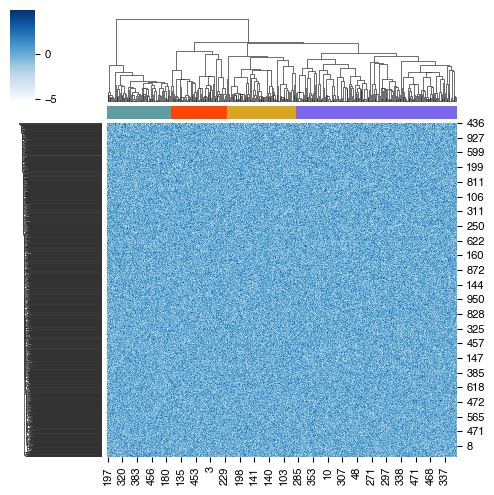

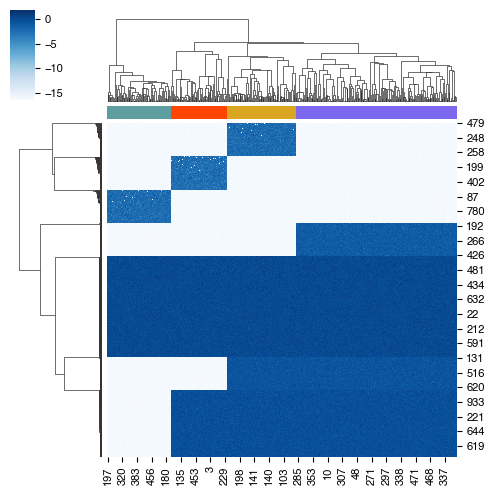

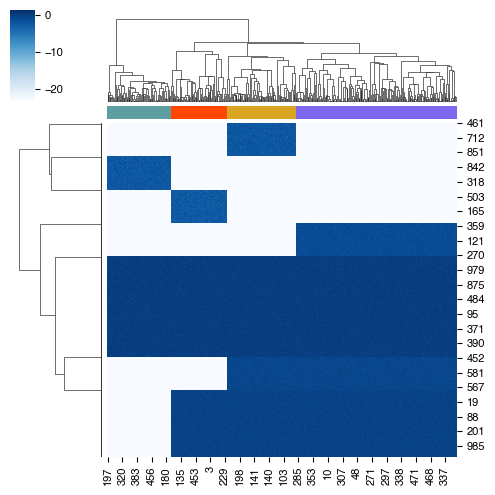

In [26]:
sns.clustermap(gamma_hat_init.cpu().numpy(), col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
sns.clustermap(gamma_hat.cpu().numpy(), col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
sns.clustermap(gamma_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))

In [27]:
end_time - start_time

847.1860129833221